In [ ]:
 # Mount Google Drive to access datasets, models, or other files stored in Drive.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Import all requried libraries.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import
 (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_squared_error
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#Connect to OCT dataset folder in Drive.

dataset_path = '/content/drive/My Drive/OCT_Dataset'

In [ ]:
# Initialise ImageDataGenerator for preprocessing and dataset splitting.

data_gen = ImageDataGenerator
 (
    rescale=1./255, # Normalises pixel values from [0, 255] to [0, 1] to improve model convergence.

    validation_split=0.2 # Reserves 20% of the data for validation.
)

In [ ]:
# Prepare the training dataset using the data generator.
# Images are resized to 128x128 pixels, loaded in batches of 32, and labels are one-hot encoded. Only the 'training' subset is loaded.

train_data = data_gen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 623 images belonging to 3 classes.


In [ ]:
# Prepare the validation dataset using the same configuration.
# Only the 'validation' subset is loaded.

val_data = data_gen.flow_from_directory
 (
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 155 images belonging to 3 classes.


In [ ]:
# Load the VGG16 model pre-trained on ImageNet, excluding its top classification layers.
# The input shape is set to 128x128x3 to match the dataset dimensions.

base_model_vgg = VGG16(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
base_model_vgg.trainable = False  # Freeze base layers

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Add custom classification layers on top of the frozen VGG16 base model.

model_vgg = models.Sequential([
    base_model_vgg,
    layers.Flatten(), # Flatten layer to convert 2D feature maps to 1D vectors.
    layers.Dense(256, activation='relu'), # Dense layer with 256 units and ReLU activation for non-linear transformation.
    layers.Dropout(0.5), # A Dropout layer with a rate of 0.5 to reduce overfitting.
    layers.Dense(3, activation='softmax') # A final Dense layer with softmax activation to output probabilities for 3 classes.
])

In [ ]:
# Compile the model with the Adam optimizer, categorical crossentropy loss.
# (Suitable for multi-class classification), and accuracy as the evaluation metric.

model_vgg.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
# Train the model using the training data for 10 epochs.
# Validation performance is monitored using the validation dataset.

history_vgg = model_vgg.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 320s 12s/step - accuracy: 0.4829 - loss: 1.5948 - val_accuracy: 0.7742 - val_loss: 0.5619
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 148s 7s/step - accuracy: 0.7422 - loss: 0.6121 - val_accuracy: 0.8710 - val_loss: 0.4504
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 145s 7s/step - accuracy: 0.7991 - loss: 0.5184 - val_accuracy: 0.8645 - val_loss: 0.3932
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 201s 7s/step - accuracy: 0.8384 - loss: 0.4149 - val_accuracy: 0.9032 - val_loss: 0.3182
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 146s 7s/step - accuracy: 0.9031 - loss: 0.3120 - val_accuracy: 0.8903 - val_loss: 0.3361
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 199s 7s/step - accuracy: 0.8885 - loss: 0.3062 - val_accuracy: 0.9161 - val_loss: 0.2890
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 204s 7s/step - accuracy: 0.8928 - loss: 0.2997 - val_accuracy: 0.9032 - val_loss: 0.3351
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 202s 7s/step - accuracy: 0.9063 - loss: 0.2761 - val_accuracy: 0.8516 - val_loss: 0

In [ ]:
# Extract the true class labels from the validation dataset.

val_labels = val_data.classes

# Generate predicted class indices from the trained model.
# 'predict' outputs probabilities; argmax selects the index of the highest probability.

val_preds = np.argmax(model_vgg.predict(val_data), axis=-1)

# Retrieve the class names from the validation data generator.
# These are derived from the folder names used in the dataset directory.

class_names = list(val_data.class_indices.keys())

5/5 ━━━━━━━━━━━━━━━━━━━━ 43s 9s/step


In [ ]:
# Evaluate the trained model on the validation dataset and print the test accuracy.

test_loss, test_acc = model_vgg.evaluate(val_data)
print(f"VGG16 Test Accuracy: {test_acc:.2f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 32s 6s/step - accuracy: 0.9061 - loss: 0.2612
VGG16 Test Accuracy: 0.92


In [ ]:
# Compute Metrics

accuracy = np.mean(val_preds == val_labels)

# Precision, Recall, and F1-score computed for each class individually.
#'zero_division=0' avoids division errors in case of no predicted samples for a class.

precision = precision_score(val_labels, val_preds, average=None, zero_division=0)
recall = recall_score(val_labels, val_preds, average=None, zero_division=0)
f1 = f1_score(val_labels, val_preds, average=None, zero_division=0)

mse = mean_squared_error(val_labels, val_preds)

auc = roc_auc_score(
    tf.keras.utils.to_categorical(val_labels),
    model_vgg.predict(val_data),
    multi_class='ovr'
    )

5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 7s/step


In [ ]:
# Organise overall performance metrics into a table for better presentation.

performance_data = {
    "Metric": ["Accuracy", "Mean Squared Error (MSE)", "Area Under the ROC Curve (AUC)"],
    "Value": [round(accuracy, 2), round(mse, 2), round(auc, 2)]
}

In [ ]:
# Display the overall evaluation metrics in a tabular format.

performance_table = pd.DataFrame(performance_data)
print("\nOverall Performance Metrics:")
print(performance_table.to_string(index=False))


Overall Performance Metrics:
                        Metric  Value
                      Accuracy   0.43
      Mean Squared Error (MSE)   1.75
Area Under the ROC Curve (AUC)   0.47


In [ ]:
# Compile class-wise precision, recall, and F1-score into a structured table.
# Rounding each metric to two decimal places for clarity.

class_metrics = {
    "Class": class_names,
    "Precision": [round(p, 2) for p in precision],
    "Recall": [round(r, 2) for r in recall],
    "F1-Score": [round(f, 2) for f in f1]
}


class_metrics_table = pd.DataFrame(class_metrics)

# Display the class-wise evaluation metrics.
print("\nClass-wise Performance Metrics:")
print(class_metrics_table.to_string(index=False))


Class-wise Performance Metrics:
Class  Precision  Recall  F1-Score
  AMD       0.44    0.46      0.45
  DME       0.25    0.20      0.22
   NO       0.45    0.45      0.45


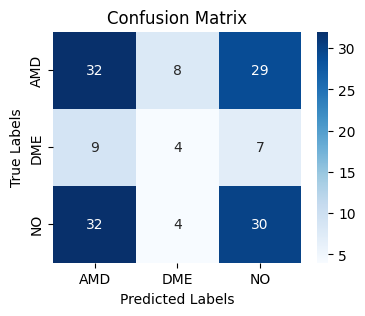

In [ ]:
# Generate and visualise the confusion matrix to assess classification performance.
# Rows represent true labels; columns represent predicted labels.

conf_matrix = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

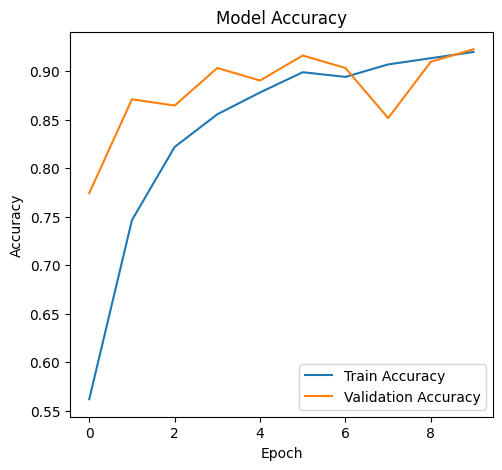

In [ ]:
# Plot training and validation accuracy and loss across epochs to visualise model performance.
plt.figure(figsize=(12, 5))


# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

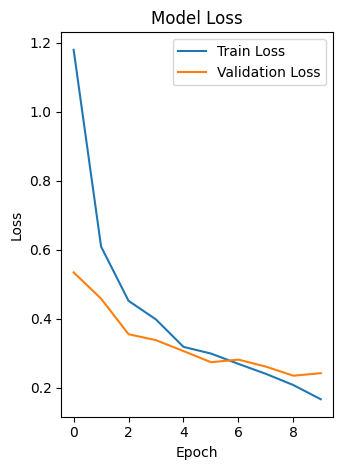

In [ ]:
# Loss Plot

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()